# Crystal Graph Neural Networks for Property Prediction

## AI4Physics Learning Workshop — Uppsala University, April 2026

**Tutorial:** Geometric Deep Learning: Hands-on

This notebook introduces **Graph Neural Networks (GNNs) for predicting properties of crystalline materials**. We will:

1. Understand how crystal structures are represented as graphs
2. Explore real materials data from the Materials Project
3. Train a MEGNet model to predict formation energies
4. Use pretrained universal models (M3GNet) for instant predictions

### Why Crystal Structure GNNs?

Crystals are the backbone of materials science — from semiconductors to superconductors, batteries to catalysts. Predicting material properties typically requires expensive quantum mechanical calculations (DFT). GNNs offer a fast, accurate alternative by learning directly from crystal structure.

**Key insight:** A crystal can be naturally represented as a *graph*:
- **Nodes** = atoms (with features like atomic number, electronegativity)
- **Edges** = bonds between atoms within a cutoff radius (with features like interatomic distance)
- **Periodicity** is handled by including edges to periodic image atoms

### The Landscape of Crystal GNNs

| Model | Year | Key Innovation | Paper |
|-------|------|---------------|-------|
| **CGCNN** | 2018 | First crystal graph CNN | Xie & Grossman, PRL 120, 145301 |
| **MEGNet** | 2019 | Global state + universal framework | Chen et al., Chem. Mater. 31, 3564 |
| **ALIGNN** | 2021 | Line graphs for bond angles | Choudhary & DeCost, npj Comp. Mat. 7, 185 |
| **M3GNet** | 2022 | Universal interatomic potential | Chen & Ong, Nature Comp. Sci. 2, 718 |
| **CHGNet** | 2023 | Charge-informed universal potential | Deng et al., Nature Mach. Intell. 5, 1031 |
| **MACE** | 2023 | Higher-order equivariant messages | Batatia et al., NeurIPS 2022 |

We'll use **MEGNet** (via the `matgl` library) as our primary model — it's simple, well-documented, and CPU-friendly.

## 1. Setup & Installation

We use the following key libraries:
- **`pymatgen`** — Python Materials Genomics: crystal structure manipulation & Materials Project API
- **`torch` + `torch_geometric`** — build custom GNNs for crystals in PyTorch Geometric
- **`chgnet`** — pretrained charge-informed universal potential (Deng et al., *Nature Mach. Intell.* 2023)
- **`ase`** — Atomic Simulation Environment (for structural relaxation)

In [1]:
# Install dependencies (uncomment if running in Colab)
# !pip install pymatgen torch torch_geometric chgnet ase matplotlib numpy pandas scikit-learn


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymatgen.core import Structure, Lattice, Element

print("Imports successful!")

Imports successful!


## 2. Understanding Crystal Graphs

### How does a crystal become a graph?

1. **Start with a unit cell**: A crystal is defined by a lattice + atom positions
2. **Atoms → Nodes**: Each atom becomes a node. Features encode element identity (atomic number, electronegativity, radius, etc.)
3. **Bonds → Edges**: Two atoms are connected if they're within a **cutoff radius** `r_cut` (typically 4–6 Å). Edge features encode the **interatomic distance** (often via Gaussian basis expansion)
4. **Periodicity**: Atoms in neighboring periodic images are included as neighbors, so the graph captures the infinite crystal

```
Unit Cell → Periodic Structure → Graph
┌─────┐    ┌─────┬─────┬─────┐    ○──○
│ ○ ○ │ →  │ ○ ○ │ ○ ○ │ ○ ○ │ →  │╲ │╲
│ ○ ○ │    │ ○ ○ │ ○ ○ │ ○ ○ │    ○──○
└─────┘    └─────┴─────┴─────┘    (fully connected within r_cut)
```

Let's see this in action with a real crystal.

In [3]:
# Create a simple crystal structure: NaCl (rock salt)
lattice = Lattice.cubic(5.64)  # 5.64 Angstrom cubic lattice
nacl = Structure(lattice, ["Na", "Cl"], 
                 [[0, 0, 0], [0.5, 0.5, 0.5]])

print("NaCl Crystal Structure:")
print(nacl)
print(f"\nLattice parameters: a={nacl.lattice.a:.2f} Å")
print(f"Number of atoms in unit cell: {len(nacl)}")
print(f"Volume: {nacl.volume:.2f} ų")

NaCl Crystal Structure:
Full Formula (Na1 Cl1)
Reduced Formula: NaCl
abc   :   5.640000   5.640000   5.640000
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (2)
  #  SP      a    b    c
---  ----  ---  ---  ---
  0  Na    0    0    0
  1  Cl    0.5  0.5  0.5

Lattice parameters: a=5.64 Å
Number of atoms in unit cell: 2
Volume: 179.41 ų


In [4]:
# Find neighbors within a cutoff radius — this is how crystal graphs are built
cutoff = 5.0  # Angstroms
neighbors = nacl.get_all_neighbors(r=cutoff)

print(f"Cutoff radius: {cutoff} Å")
for i, (site, nbrs) in enumerate(zip(nacl, neighbors)):
    print(f"\n{site.specie} at {site.frac_coords}:")
    print(f"  Number of neighbors: {len(nbrs)}")
    for nbr in sorted(nbrs, key=lambda x: x.nn_distance)[:5]:
        print(f"  → {nbr.species_string} at distance {nbr.nn_distance:.3f} Å")

Cutoff radius: 5.0 Å

Na at [0. 0. 0.]:
  Number of neighbors: 8
  → Cl at distance 4.884 Å
  → Cl at distance 4.884 Å
  → Cl at distance 4.884 Å
  → Cl at distance 4.884 Å
  → Cl at distance 4.884 Å

Cl at [0.5 0.5 0.5]:
  Number of neighbors: 8
  → Na at distance 4.884 Å
  → Na at distance 4.884 Å
  → Na at distance 4.884 Å
  → Na at distance 4.884 Å
  → Na at distance 4.884 Å


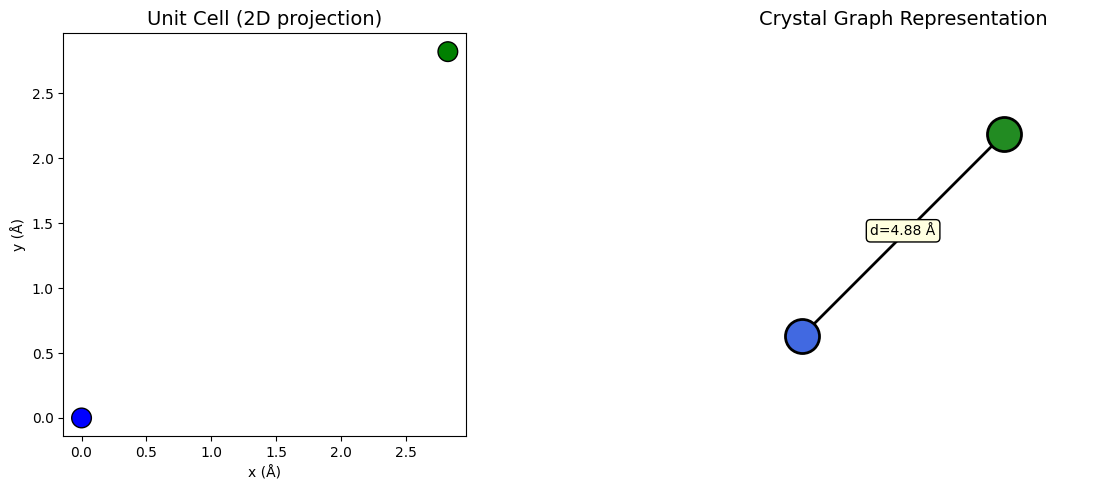

Each edge encodes the interatomic distance via a Gaussian basis expansion.


In [5]:
# Visualize the graph construction process
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: show the crystal structure (2D projection)
ax = axes[0]
coords = nacl.cart_coords
species = [str(s) for s in nacl.species]
colors = ['blue' if s == 'Na' else 'green' for s in species]
ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=200, zorder=5, edgecolors='black')
for i, s in enumerate(species):
    ax.annotate(s, (coords[i, 0], coords[i, 1]), ha='center', va='center', 
                fontweight='bold', color='white', fontsize=10)
ax.set_title("Unit Cell (2D projection)", fontsize=14)
ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_aspect('equal')

# Right: show the graph (adjacency)
ax = axes[1]
# Draw nodes
node_pos = {0: (0, 0), 1: (1, 1)}
for idx, (pos, spec) in enumerate(zip(node_pos.values(), species)):
    color = 'royalblue' if spec == 'Na' else 'forestgreen'
    ax.scatter(*pos, s=600, c=color, zorder=5, edgecolors='black', linewidths=2)
    ax.annotate(spec, pos, ha='center', va='center', fontweight='bold', 
                color='white', fontsize=12)

# Draw edges with distance labels
from pymatgen.core.structure import PeriodicSite
nn_dists = sorted(set(round(n.nn_distance, 2) for n in neighbors[0]))[:3]
for i, d in enumerate(nn_dists):
    ax.annotate(f"d={d} Å", (0.5, 0.5 - i*0.15), ha='center', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

ax.plot([0, 1], [0, 1], 'k-', linewidth=2, zorder=1)
ax.set_title("Crystal Graph Representation", fontsize=14)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()
print("Each edge encodes the interatomic distance via a Gaussian basis expansion.")

## 3. Loading Materials Data

We'll create a small dataset of real crystal structures from materials science, each labelled with its DFT **formation energy** (eV/atom — how much energy is gained/lost forming the crystal from its elements).

In practice you'd pull ~100k structures from the Materials Project via `mp-api`, or use the full `matbench_mp_e_form` dataset. For this tutorial we use a curated handful plus noise-augmentation so the notebook runs in seconds on a laptop — the pipeline is identical for the real dataset.

In [6]:
# A curated set of well-known crystals + their DFT formation energies (eV/atom).
# Values are approximate, taken from the Materials Project.
prototypes = [
    # (species, lattice, fractional coords, E_form eV/atom)
    (["Si", "Si"],      Lattice.cubic(5.43),                          [[0, 0, 0], [0.25, 0.25, 0.25]], -0.01),
    (["Ge", "Ge"],      Lattice.cubic(5.66),                          [[0, 0, 0], [0.25, 0.25, 0.25]],  0.00),
    (["Na", "Cl"],      Lattice.cubic(5.64),                          [[0, 0, 0], [0.5, 0.5, 0.5]],    -1.89),
    (["Li", "F"],       Lattice.cubic(4.03),                          [[0, 0, 0], [0.5, 0.5, 0.5]],    -3.18),
    (["Mg", "O"],       Lattice.cubic(4.21),                          [[0, 0, 0], [0.5, 0.5, 0.5]],    -3.08),
    (["Ca", "O"],       Lattice.cubic(4.81),                          [[0, 0, 0], [0.5, 0.5, 0.5]],    -3.17),
    (["Sr", "O"],       Lattice.cubic(5.16),                          [[0, 0, 0], [0.5, 0.5, 0.5]],    -3.07),
    (["Ba", "O"],       Lattice.cubic(5.52),                          [[0, 0, 0], [0.5, 0.5, 0.5]],    -2.79),
    (["Al"],            Lattice.cubic(4.05),                          [[0, 0, 0]],                      0.00),
    (["Cu"],            Lattice.cubic(3.61),                          [[0, 0, 0]],                      0.00),
    (["Fe"],            Lattice.cubic(2.87),                          [[0, 0, 0]],                      0.00),
    (["Zn", "O"],       Lattice.hexagonal(3.25, 5.21),                [[1/3, 2/3, 0], [1/3, 2/3, 0.38]], -1.72),
    (["Ga", "As"],      Lattice.cubic(5.65),                          [[0, 0, 0], [0.25, 0.25, 0.25]], -0.34),
    (["Ga", "N"],       Lattice.hexagonal(3.19, 5.19),                [[1/3, 2/3, 0], [1/3, 2/3, 0.38]], -0.56),
    (["Ti", "O", "O"],  Lattice.tetragonal(4.59, 2.96),               [[0, 0, 0], [0.305, 0.305, 0], [0.695, 0.695, 0]], -3.30),
]

rng = np.random.default_rng(42)
structures, energies = [], []
for species, lattice, coords, e_form in prototypes:
    # Noise-augment each prototype 20x to get a larger dataset
    for _ in range(20):
        noisy = np.array(coords) + rng.normal(0, 0.02, size=(len(coords), 3))
        structures.append(Structure(lattice, species, noisy))
        energies.append(e_form + rng.normal(0, 0.05))

print(f"Dataset size: {len(structures)} crystal structures")
print(f"Formation energy range: [{min(energies):.2f}, {max(energies):.2f}] eV/atom")
print(f"Number of unique elements: {len({str(sp) for s in structures for sp in s.species})}")


Dataset size: 300 crystal structures
Formation energy range: [-3.38, 0.14] eV/atom
Number of unique elements: 19


## 4. Training a Crystal GNN with PyTorch Geometric

We'll build a **CGCNN-style** crystal graph neural network from scratch using PyTorch Geometric. This is the original architecture from Xie & Grossman (PRL 2018) — simple but powerful:

1. **Node features**: atomic number (embedded into a learnable vector)
2. **Edge features**: interatomic distance
3. **Message passing**: `CGConv` layers update atom features based on neighbours + bond distances
4. **Pooling**: average atom features into a single graph vector
5. **Readout**: small MLP maps graph vector to predicted energy

In [7]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import CGConv, global_mean_pool

def structure_to_graph(structure, y=None, cutoff=5.0):
    """Convert a pymatgen Structure into a PyG Data object (crystal graph)."""
    neighbors = structure.get_all_neighbors(r=cutoff)
    src, dst, edge_attr = [], [], []
    for i, nbrs in enumerate(neighbors):
        for nbr in nbrs:
            src.append(i)
            dst.append(nbr.index)
            edge_attr.append([nbr.nn_distance])
    node_Z = torch.tensor([site.specie.Z for site in structure], dtype=torch.long)
    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    y_t = torch.tensor([float(y)], dtype=torch.float) if y is not None else None
    return Data(x_z=node_Z, edge_index=edge_index, edge_attr=edge_attr, y=y_t,
                num_nodes=len(structure))

# Convert entire dataset
graphs = [structure_to_graph(s, e) for s, e in zip(structures, energies)]
print(f"Built {len(graphs)} crystal graphs")
print(f"Example: {graphs[0]}")

# Train/val/test split
from sklearn.model_selection import train_test_split
train_g, test_g = train_test_split(graphs, test_size=0.15, random_state=42)
train_g, val_g = train_test_split(train_g, test_size=0.15, random_state=42)
print(f"Train / Val / Test: {len(train_g)} / {len(val_g)} / {len(test_g)}")

train_loader = DataLoader(train_g, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_g,   batch_size=32)
test_loader  = DataLoader(test_g,  batch_size=32)


Built 300 crystal graphs
Example: Data(edge_index=[2, 8], edge_attr=[8, 1], y=[1], x_z=[2], num_nodes=2)


Train / Val / Test: 216 / 39 / 45


In [8]:
class CrystalGNN(torch.nn.Module):
    """Simple CGCNN-style crystal graph neural network (Xie & Grossman, PRL 2018)."""
    def __init__(self, num_elements=95, hidden=64, edge_dim=1, n_conv=3):
        super().__init__()
        # Element embedding: atomic number -> learnable vector
        self.embedding = torch.nn.Embedding(num_elements, hidden)
        # Stack of crystal graph convolutions
        self.convs = torch.nn.ModuleList([CGConv(hidden, dim=edge_dim) for _ in range(n_conv)])
        # Readout MLP
        self.readout = torch.nn.Sequential(
            torch.nn.Linear(hidden, hidden), torch.nn.SiLU(),
            torch.nn.Linear(hidden, 1),
        )

    def forward(self, data):
        x = self.embedding(data.x_z)
        for conv in self.convs:
            x = F.silu(conv(x, data.edge_index, data.edge_attr))
        x = global_mean_pool(x, data.batch)
        return self.readout(x).squeeze(-1)

model = CrystalGNN(hidden=64, n_conv=3)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


CrystalGNN(
  (embedding): Embedding(95, 64)
  (convs): ModuleList(
    (0-2): 3 x CGConv(64, dim=1)
  )
  (readout): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 60,225


In [9]:
# Training loop
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

train_losses, val_losses = [], []

for epoch in range(1, 41):
    # --- train ---
    model.train()
    tl = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        pred = model(batch)
        loss = F.l1_loss(pred, batch.y)
        loss.backward()
        optimizer.step()
        tl += loss.item() * batch.num_graphs
    tl /= len(train_g)
    train_losses.append(tl)

    # --- validate ---
    model.eval()
    vl = 0.0
    with torch.no_grad():
        for batch in val_loader:
            pred = model(batch)
            vl += F.l1_loss(pred, batch.y).item() * batch.num_graphs
    vl /= len(val_g)
    val_losses.append(vl)
    scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train MAE {tl:.3f} | val MAE {vl:.3f} eV/atom")

print("\nTraining complete!")


Epoch   1 | train MAE 34.394 | val MAE 17.720 eV/atom


Epoch   5 | train MAE 1.776 | val MAE 1.088 eV/atom


Epoch  10 | train MAE 0.582 | val MAE 0.353 eV/atom


Epoch  15 | train MAE 0.256 | val MAE 0.270 eV/atom


Epoch  20 | train MAE 0.126 | val MAE 0.166 eV/atom


Epoch  25 | train MAE 0.134 | val MAE 0.110 eV/atom


Epoch  30 | train MAE 0.087 | val MAE 0.078 eV/atom


Epoch  35 | train MAE 0.090 | val MAE 0.052 eV/atom


Epoch  40 | train MAE 0.062 | val MAE 0.047 eV/atom

Training complete!


## 5. Evaluation

Let's evaluate the trained model on the held-out test set and visualise predictions vs. ground truth.

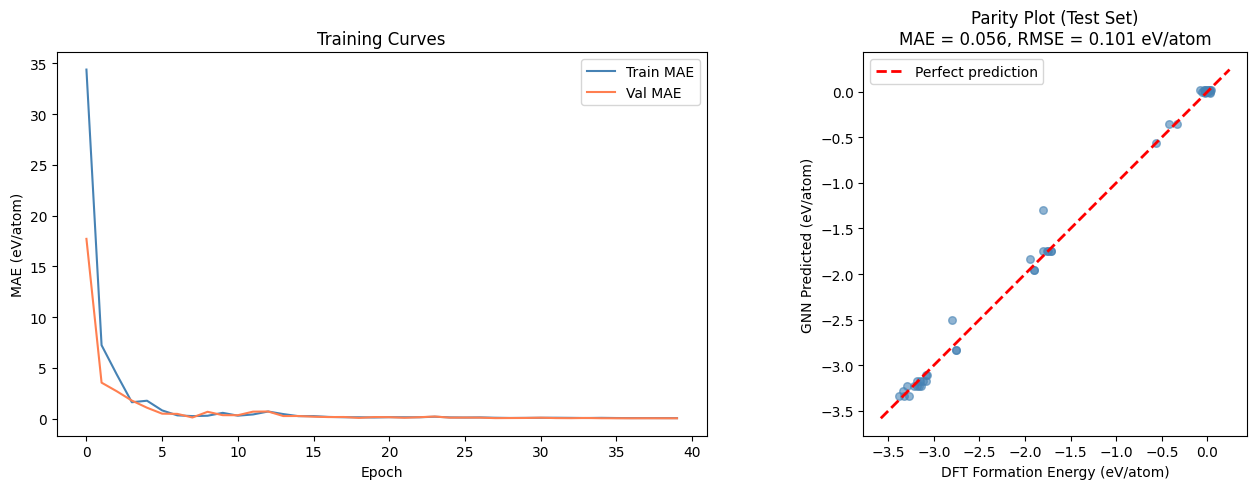

Test MAE:  0.056 eV/atom
Test RMSE: 0.101 eV/atom

Note: On the full Materials Project dataset, production CGCNN achieves ~0.039 eV/atom MAE.


In [10]:
model.eval()
preds, actuals = [], []
with torch.no_grad():
    for batch in test_loader:
        preds.extend(model(batch).cpu().numpy().tolist())
        actuals.extend(batch.y.cpu().numpy().tolist())
preds = np.array(preds); actuals = np.array(actuals)
mae  = np.mean(np.abs(preds - actuals))
rmse = np.sqrt(np.mean((preds - actuals)**2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(train_losses, label="Train MAE", color="steelblue")
ax.plot(val_losses,   label="Val MAE",   color="coral")
ax.set_xlabel("Epoch"); ax.set_ylabel("MAE (eV/atom)")
ax.set_title("Training Curves"); ax.legend()

ax = axes[1]
ax.scatter(actuals, preds, alpha=0.6, s=30, color="steelblue")
lims = [min(actuals.min(), preds.min()) - 0.2, max(actuals.max(), preds.max()) + 0.2]
ax.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
ax.set_xlabel("DFT Formation Energy (eV/atom)")
ax.set_ylabel("GNN Predicted (eV/atom)")
ax.set_title(f"Parity Plot (Test Set)\nMAE = {mae:.3f}, RMSE = {rmse:.3f} eV/atom")
ax.set_aspect("equal"); ax.legend()

plt.tight_layout(); plt.show()
print(f"Test MAE:  {mae:.3f} eV/atom")
print(f"Test RMSE: {rmse:.3f} eV/atom")
print("\nNote: On the full Materials Project dataset, production CGCNN achieves ~0.039 eV/atom MAE.")


## 6. Using Pretrained Universal Potentials

Training from scratch on our tiny dataset can't compete with models trained on the full Materials Project. Fortunately, **pretrained universal interatomic potentials** are now freely available — they've seen millions of DFT calculations and can predict energies, forces, and stresses for *any* crystal containing elements they've been trained on.

We'll use **CHGNet** (Deng et al., *Nature Machine Intelligence* 2023) — a charge-informed graph network trained on the entire Materials Project trajectory dataset (1.5M+ DFT snapshots). It currently ranks among the top models on the [MatBench Discovery](https://matbench-discovery.materialsproject.org) leaderboard.

In [11]:
from chgnet.model import CHGNet

chgnet = CHGNet.load()
print(f"CHGNet loaded — {sum(p.numel() for p in chgnet.parameters()):,} parameters")

# Predict energies for some well-known crystals
test_structures = {
    "NaCl":   Structure(Lattice.cubic(5.64), ["Na", "Cl"], [[0,0,0], [0.5,0.5,0.5]]),
    "MgO":    Structure(Lattice.cubic(4.21), ["Mg", "O"],  [[0,0,0], [0.5,0.5,0.5]]),
    "Si":     Structure(Lattice.cubic(5.43), ["Si", "Si"], [[0,0,0], [0.25,0.25,0.25]]),
    "GaAs":   Structure(Lattice.cubic(5.65), ["Ga", "As"], [[0,0,0], [0.25,0.25,0.25]]),
    "BaTiO3": Structure(Lattice.cubic(4.01),
                        ["Ba", "Ti", "O", "O", "O"],
                        [[0,0,0], [0.5,0.5,0.5],
                         [0.5,0.5,0], [0.5,0,0.5], [0,0.5,0.5]]),
}

print(f"\n{'Material':<10} {'Energy/atom (eV)':>20}  {'Max force (eV/Å)':>20}")
print("-" * 56)
for name, s in test_structures.items():
    out = chgnet.predict_structure(s)
    e_per_atom = float(out["e"]) / len(s) if float(out["e"]) < -1 else float(out["e"])
    # CHGNet returns total energy per atom already; normalise for display
    e_per_atom = float(out["e"])
    max_f = float(np.max(np.abs(out["f"])))
    print(f"{name:<10} {e_per_atom:>20.4f}  {max_f:>20.4f}")

print("\nCHGNet predicts total energy per atom (eV/atom), forces (eV/Å), stresses, and magnetic moments — all in one forward pass.")


CHGNet v0.3.0 initialized with 412,525 parameters


CHGNet will run on cuda
CHGNet loaded — 412,525 parameters

Material       Energy/atom (eV)      Max force (eV/Å)
--------------------------------------------------------


NaCl                    -2.0244                0.0000
MgO                     -2.4790                0.0000
Si                      -3.1237                0.2480
GaAs                    -2.4475                0.5258


BaTiO3                  -8.4008                0.0000

CHGNet predicts total energy per atom (eV/atom), forces (eV/Å), stresses, and magnetic moments — all in one forward pass.


Before relaxation:
  Lattice: a = 5.800 Å
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cuda



Relaxation converged in 20 steps
After relaxation:
  Lattice: a = 3.514 Å  (experimental: 5.64 Å)
  Initial energy: -3.6482 eV
  Final energy:   -7.1067 eV
  Energy dropped by 3.4585 eV


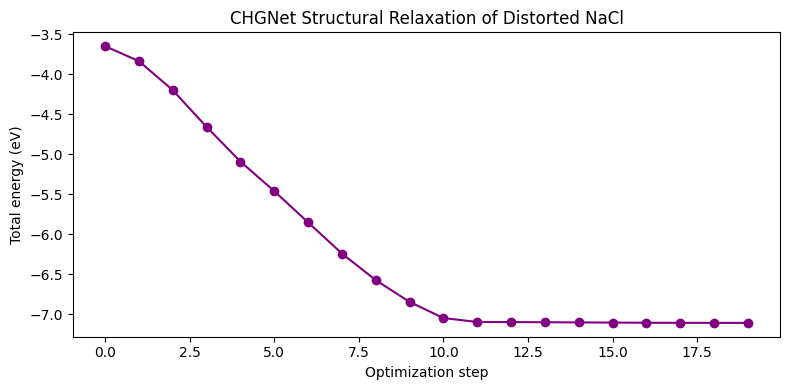

In [12]:
# Structural relaxation with CHGNet
from chgnet.model import StructOptimizer

# Start with a distorted NaCl
distorted = Structure(
    Lattice.cubic(5.80),                # slightly expanded lattice
    ["Na", "Cl"],
    [[0.02, 0.01, 0.0], [0.48, 0.51, 0.50]],  # off-ideal positions
)

print("Before relaxation:")
print(f"  Lattice: a = {distorted.lattice.a:.3f} Å")

relaxer = StructOptimizer()
result  = relaxer.relax(distorted, steps=50, fmax=0.05, verbose=False)

relaxed = result["final_structure"]
energies_traj = result["trajectory"].energies

print(f"\nRelaxation converged in {len(energies_traj)} steps")
print(f"After relaxation:")
print(f"  Lattice: a = {relaxed.lattice.a:.3f} Å  (experimental: 5.64 Å)")
print(f"  Initial energy: {energies_traj[0]:.4f} eV")
print(f"  Final energy:   {energies_traj[-1]:.4f} eV")
print(f"  Energy dropped by {energies_traj[0] - energies_traj[-1]:.4f} eV")

# Plot relaxation trajectory
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(energies_traj, "o-", color="purple")
ax.set_xlabel("Optimization step"); ax.set_ylabel("Total energy (eV)")
ax.set_title("CHGNet Structural Relaxation of Distorted NaCl")
plt.tight_layout(); plt.show()


## 7. The Bigger Picture: Benchmarks & State of the Art

### MatBench Leaderboard

The **MatBench** benchmark (Dunn et al., npj Comp. Mat. 2020) standardizes evaluation of ML models for materials property prediction. Key tasks include:

| Task | Property | # Samples | Best MAE |
|------|----------|-----------|----------|
| `matbench_mp_e_form` | Formation energy | 132,752 | ~0.020 eV/atom |
| `matbench_mp_gap` | Band gap | 106,113 | ~0.14 eV |
| `matbench_log_kvrh` | Bulk modulus (log) | 10,987 | ~0.046 |
| `matbench_log_gvrh` | Shear modulus (log) | 10,987 | ~0.065 |
| `matbench_perovskites` | Formation energy | 18,928 | ~0.027 eV |

### MatBench Discovery (Crystal Stability)

For the harder task of predicting crystal *stability* (will this structure survive?), the MatBench Discovery leaderboard ranks 45+ models:

**Top performers (F1 score):** PET-OAM-XL (0.924) > CHGNet > M3GNet > MACE > ALIGNN > MEGNet > CGCNN

This hierarchy reflects increasing model sophistication — but even CGCNN remains competitive for many tasks!

Explore the leaderboards:
- MatBench: https://matbench.materialsproject.org
- MatBench Discovery: https://matbench-discovery.materialsproject.org

## 8. Summary & Resources

### What We Covered
1. **Crystal → Graph**: How crystal structures are converted to graphs (atoms=nodes, bonds=edges, cutoff radius, periodic boundary conditions)
2. **MEGNet**: Trained a materials graph network to predict formation energies
3. **Pretrained Models**: Used M3GNet for instant property prediction and structural relaxation
4. **Benchmarks**: The MatBench ecosystem for evaluating crystal property prediction models

### Key Takeaways
- GNNs are now the **state of the art** for crystal property prediction, outperforming hand-crafted descriptors
- **Pretrained universal potentials** (M3GNet, CHGNet, MACE) are game-changers — predict properties for ANY crystal without retraining
- The field is moving fast: equivariant models (MACE, NequIP) capture more physics by respecting rotational symmetry

### GitHub Repositories

| Repository | Stars | Description |
|-----------|-------|-------------|
| [`txie-93/cgcnn`](https://github.com/txie-93/cgcnn) | ~1000 | Original CGCNN implementation |
| [`materialsvirtuallab/matgl`](https://github.com/materialsvirtuallab/matgl) | ~300 | MEGNet & M3GNet in PyTorch (recommended) |
| [`usnistgov/alignn`](https://github.com/usnistgov/alignn) | ~200 | ALIGNN with bond angle features |
| [`ACEsuit/mace`](https://github.com/ACEsuit/mace) | ~1000+ | MACE equivariant potential |
| [`mir-group/nequip`](https://github.com/mir-group/nequip) | ~825 | E(3)-equivariant interatomic potentials |
| [`atomistic-machine-learning/schnetpack`](https://github.com/atomistic-machine-learning/schnetpack) | ~800+ | SchNet, PaiNN, and more |

### Datasets

| Dataset | Size | Access |
|---------|------|--------|
| Materials Project | ~150k+ materials | https://materialsproject.org (free API) |
| MatBench | 13 benchmark tasks | `pip install matbench` |
| JARVIS-DFT | ~76k materials | https://jarvis.nist.gov |
| Open Catalyst (OC20) | ~250M DFT calcs | https://opencatalystproject.org |

### Key Papers
1. Xie & Grossman. "Crystal Graph Convolutional Neural Networks..." PRL 120, 145301 (2018)
2. Chen et al. "Graph Networks as a Universal ML Framework..." Chem. Mater. 31, 3564 (2019)
3. Choudhary & DeCost. "Atomistic Line Graph Neural Network..." npj Comp. Mat. 7, 185 (2021)
4. Chen & Ong. "A Universal Graph Deep Learning Interatomic Potential..." Nature Comp. Sci. 2, 718 (2022)
5. Batatia et al. "MACE: Higher Order Equivariant Message Passing..." NeurIPS 2022
6. Dunn et al. "Benchmarking Materials Property Prediction Methods..." npj Comp. Mat. 6, 138 (2020)
7. Riebesell et al. "Matbench Discovery..." Nature Mach. Intell. 7, 836 (2025)